In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from PIL import Image



# 모델 분석 및 시각화 도구
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
import os
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 모델 설계
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, Flatten, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
# 모델 분석 및 시각화 도구
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from PIL import Image
from collections import Counter
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn (데이터 전처리 및 모델 평가)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

# 모델 설계
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy

# 모델 구조 및 레이어
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D,
Flatten, Dropout, BatchNormalization, Embedding,
LeakyReLU, GlobalAveragePooling2D, concatenate)
from tensorflow.keras.layers import Lambda, Add, Activation, Multiply

# 사전 훈련된 모델
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2, MobileNetV3Small, VGG16, InceptionV3, Xception, DenseNet121

# 컴파일 및 훈련 관련
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


In [4]:
# 데이터셋 경로
dataset_path = "/content/drive/MyDrive/ACK2025_Wafer/YOLO/YOLO_Dataset_v2"

# 클래스와 라벨 매핑 (폴더 이름 기반) # << 변경: 다중 클래스로 확장
classes = {
    "Center": 0,
    "Donut": 1,
    "Edge-Loc": 2,
    "Edge-Ring": 3,
    "Loc": 4,
    "Near-full": 5,
    "Random": 6,
    "Scratch": 7
}

# 데이터와 라벨 저장
image_data = []
labels = []

print("데이터 로딩 시작...")
for class_name, label in classes.items():
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_folder):
        print(f"경고: {class_folder} 디렉토리를 찾을 수 없습니다. 건너뜁니다.")
        continue
    for image_file in os.listdir(class_folder):
        image_path = os.path.join(class_folder, image_file)
        try:
            img = Image.open(image_path).convert("RGB")
            img = img.resize((128, 128))
            image_data.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print(f"이미지 로드 실패: {image_path}, 오류: {e}")

X = np.array(image_data)
y = np.array(labels)

print("\n원본 라벨 분포:")
label_counts = dict(zip(classes.keys(), [np.sum(y == v) for v in classes.values()]))
print(label_counts)

데이터 로딩 시작...

원본 라벨 분포:
{'Center': np.int64(2000), 'Donut': np.int64(555), 'Edge-Loc': np.int64(2000), 'Edge-Ring': np.int64(2000), 'Loc': np.int64(2000), 'Near-full': np.int64(149), 'Random': np.int64(866), 'Scratch': np.int64(1193)}


--- 원본 데이터 분포 ---
클래스 'Center' (0): 2000개
클래스 'Donut' (1): 555개
클래스 'Edge-Loc' (2): 2000개
클래스 'Edge-Ring' (3): 2000개
클래스 'Loc' (4): 2000개
클래스 'Near-full' (5): 149개
클래스 'Random' (6): 866개
클래스 'Scratch' (7): 1193개

데이터 증강 기준 (최대 샘플 수): 2000개
'Donut' 클래스 증강 시작... (목표: 1445개 생성)
'Near-full' 클래스 증강 시작... (목표: 1851개 생성)
'Random' 클래스 증강 시작... (목표: 1134개 생성)
'Scratch' 클래스 증강 시작... (목표: 807개 생성)

--- 데이터 증강 이후 최종 분포 ---
클래스 'Center' (0): 2000개
클래스 'Donut' (1): 2000개
클래스 'Edge-Loc' (2): 2000개
클래스 'Edge-Ring' (3): 2000개
클래스 'Loc' (4): 2000개
클래스 'Near-full' (5): 2000개
클래스 'Random' (6): 2000개
클래스 'Scratch' (7): 2000개


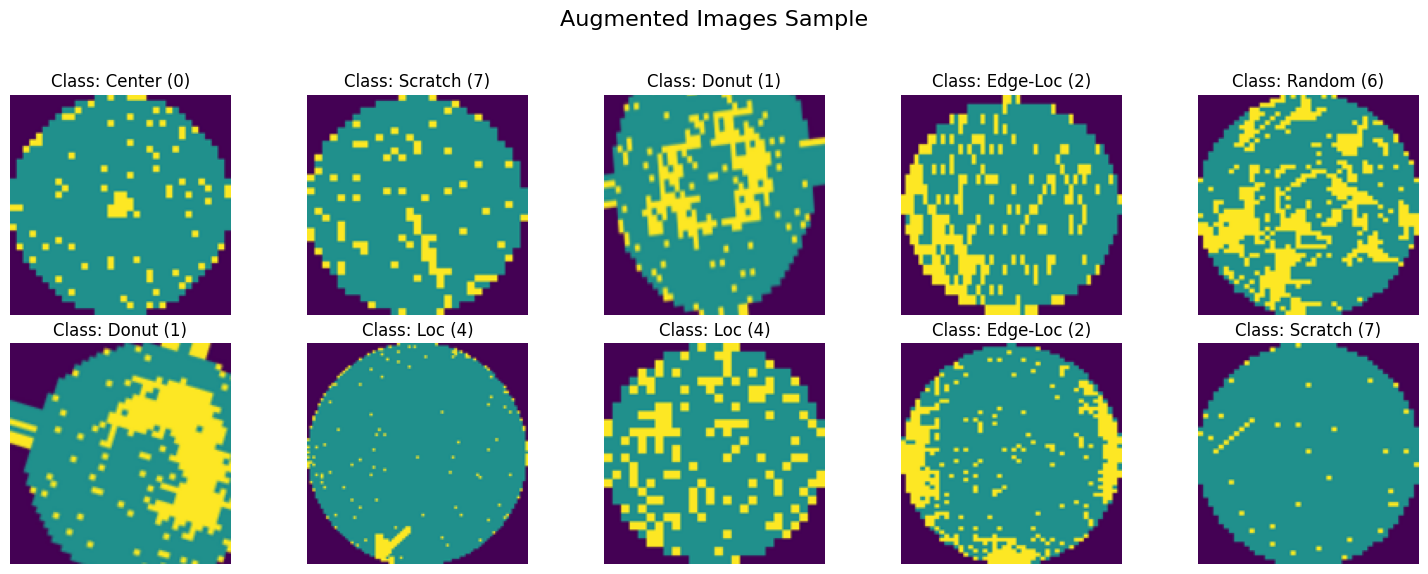

In [5]:

# 1. 데이터 증강 객체 생성
datagen = ImageDataGenerator(
    rotation_range=20,       # 회전 범위 증가
    width_shift_range=0.15,  # 이동 범위 증가
    height_shift_range=0.15,
    shear_range=0.2,         # 전단 변환 범위 증가
    zoom_range=0.2,          # 확대/축소 범위 증가
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. 클래스별 데이터 수 파악 및 최대값(기준) 설정
unique_classes, class_counts = np.unique(y, return_counts=True)
majority_count = np.max(class_counts)
class_names = list(classes.keys())

print("--- 원본 데이터 분포 ---")
for cls, count in zip(unique_classes, class_counts):
    print(f"클래스 '{class_names[cls]}' ({cls}): {count}개")
print(f"\n데이터 증강 기준 (최대 샘플 수): {majority_count}개")

# 3. 각 클래스를 순회하며 부족한 만큼 데이터 증강
X_balanced = list(X)  # 원본 데이터를 리스트로 변환
y_balanced = list(y)

for cls, count in zip(unique_classes, class_counts):
    if count < majority_count:
        # 현재 처리 중인 클래스의 원본 이미지들
        class_images = X[y == cls]

        # 증강이 필요한 이미지 수
        n_to_generate = majority_count - count
        print(f"'{class_names[cls]}' 클래스 증강 시작... (목표: {n_to_generate}개 생성)")

        # 필요한 만큼만 증강 이미지 생성
        generated_count = 0
        while generated_count < n_to_generate:
            # 증강할 원본 이미지를 무작위로 선택
            random_image = class_images[np.random.randint(0, len(class_images))]
            random_image = random_image.reshape((1, *random_image.shape))

            # datagen.flow를 사용하여 증강 이미지 생성
            for batch in datagen.flow(random_image, batch_size=1):
                augmented_image = batch[0].astype('uint8')
                X_balanced.append(augmented_image)
                y_balanced.append(cls)
                generated_count += 1
                break  # 1개만 생성하고 루프 탈출

# 4. 리스트를 Numpy 배열로 변환하고 섞기
X_balanced = np.array(X_balanced)
y_balanced = np.array(y_balanced)
X_balanced, y_balanced = shuffle(X_balanced, y_balanced, random_state=42)

# 5. 최종 결과 확인
print("\n--- 데이터 증강 이후 최종 분포 ---")
final_counts = dict(zip(*np.unique(y_balanced, return_counts=True)))
for cls, count in final_counts.items():
    print(f"클래스 '{class_names[cls]}' ({cls}): {count}개")

# 증강된 이미지 몇 개를 시각화 (임의의 클래스)
plt.figure(figsize=(15, 6))
plt.suptitle("Augmented Images Sample", fontsize=16)
for i in range(10):
    # 원본 데이터 개수 이후의 인덱스에서 이미지를 선택하여 증강된 이미지만 표시
    idx = np.random.randint(len(X), len(X_balanced))
    image = X_balanced[idx]
    label = y_balanced[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]} ({label})")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
# 정규화된 데이터를 사용합니다.
X_normalized = X_balanced / 255.0

# 훈련 셋(80%)과 테스트(검증용) 셋(20%)으로 분리합니다.
# stratify 옵션으로 각 셋의 클래스 비율을 동일하게 유지합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y_balanced,
    test_size=0.2,  # 테스트(검증용) 셋을 20%로 지정
    random_state=42,
    stratify=y_balanced
)

print("--- 데이터 분할 결과 (80:20) ---")
print(f"훈련 데이터 형태: {X_train.shape}")
print(f"테스트(검증용) 데이터 형태: {X_test.shape}")

--- 데이터 분할 결과 (80:20) ---
훈련 데이터 형태: (12800, 128, 128, 3)
테스트(검증용) 데이터 형태: (3200, 128, 128, 3)


In [7]:
# 모델 결과 시각화 함수
def plot_history(history, main_title):
    plt.figure(figsize=(12, 5))

    # 전체 타이틀
    plt.suptitle(main_title, fontsize=20, fontweight='bold')

    # 정확도
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()

    # 손실
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.92])  # 전체 타이틀 공간 확보
    plt.show()

# 조기 종료 콜백 정의
early_stopping = EarlyStopping(
    monitor='val_loss',   # 검증 손실을 모니터링
    patience=10,           # 개선이 없을 때 대기할 에포크 수
    restore_best_weights=True  # 최적의 가중치를 복원
)


def display_classification_report(y_true, y_pred_classes, class_names):
    print("--- Classification Report ---\n")
    report = classification_report(y_true, y_pred_classes, target_names=class_names, zero_division=0)
    print(report)


def plot_confusion_matrices(y_true, y_pred_classes, class_names):
    # 일반 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred_classes)
    # 정규화된 혼동 행렬 계산
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle('Confusion Matrix Comparison', fontsize=16, fontweight='bold')

    # 왼쪽: 일반 혼동 행렬
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Counts)')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # 오른쪽: 정규화된 혼동 행렬
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Normalized Confusion Matrix (Recall)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    for ax in axes:
        ax.tick_params(axis='x', labelrotation=45)
        ax.tick_params(axis='y', labelrotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



class_names = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full','Random', 'Scratch']


## **DNN**

In [8]:
# Build the ANN model

model_dnn = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(256, activation='relu'),  # 은닉층
    Dropout(0.2),
    Dense(128, activation='relu'),  # 은닉층
    Dropout(0.2),
    Dense(8, activation='softmax')
])

model_dnn.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


model_dnn.summary()

# 모델 학습
hist = model_dnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,617,096 (48.13 MB)

 Trainable params: 12,617,096 (48.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4715 - loss: 1.4751 - val_accuracy: 0.7394 - val_loss: 0.7242
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6704 - loss: 0.8695 - val_accuracy: 0.7791 - val_loss: 0.5900
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7203 - loss: 0.7417 - val_accuracy: 0.7900 - val_loss: 0.5423
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7281 - loss: 0.7019 - val_accuracy: 0.7656 - val_loss: 0.5496
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7471 - loss: 0.6502 - val_accuracy: 0.8091 - val_loss: 0.5499
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7646 - loss: 0.6140 - val_accuracy: 0.8000 - val_loss: 0.5426
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7710 - loss: 0.5930 - val_accuracy: 0.7953 - val_loss: 0.5420
Epoch 8/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7732 - loss: 0.5679 - val_accuracy: 0.

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.8200

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.91      0.94      0.93       400
       Donut       0.86      0.81      0.83       400
    Edge-Loc       0.64      0.85      0.73       400
   Edge-Ring       0.96      0.95      0.96       400
         Loc       0.63      0.60      0.61       400
   Near-full       0.99      0.99      0.99       400
      Random       0.86      0.87      0.87       400
     Scratch       0.73      0.55      0.63       400

    accuracy                           0.82      3200
   macro avg       0.82      0.82      0.82      3200
weighted avg       0.82      0.82      0.82      3200



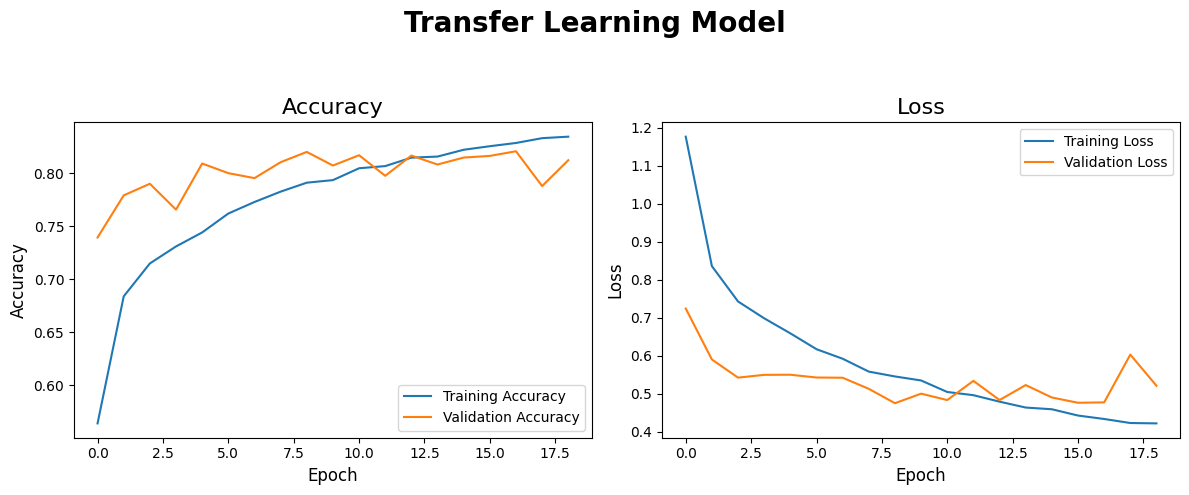

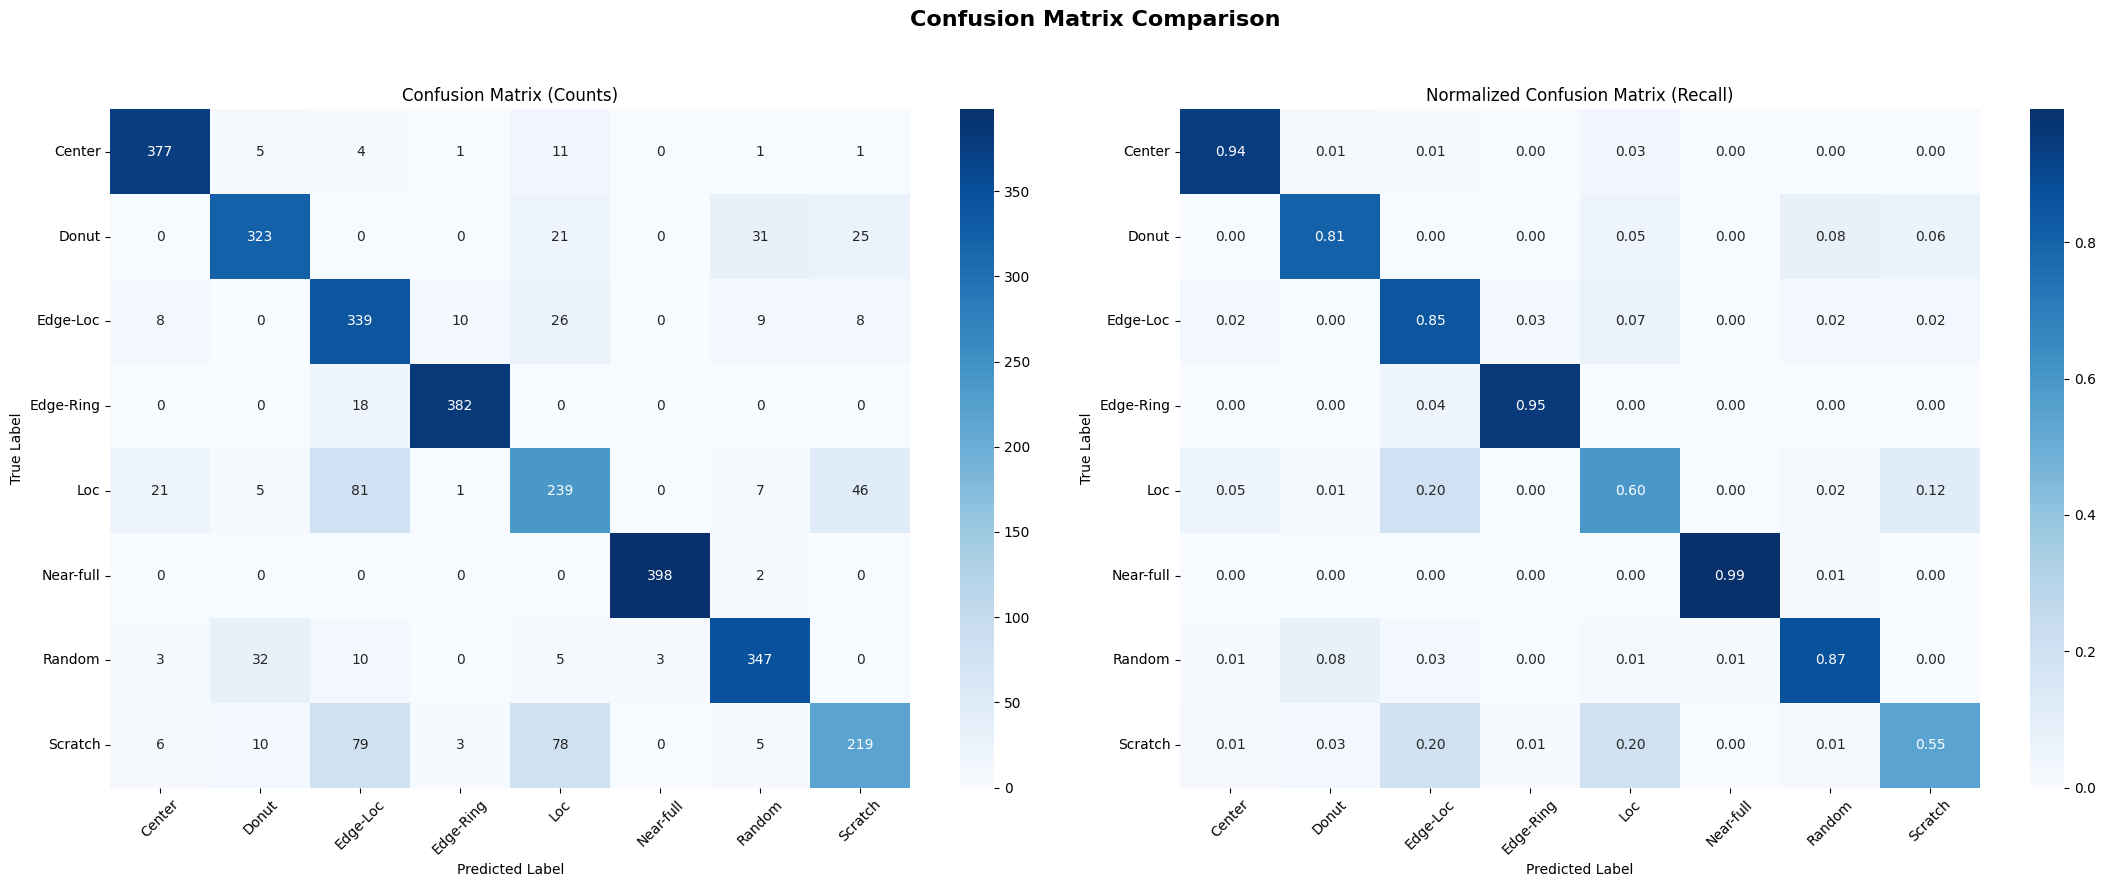

In [9]:
y_pred_probs = model_dnn.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "Transfer Learning Model")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **CNN**

In [10]:
# CNN 모델 정의
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(8, activation='softmax')
])

cnn_optimizer = Adam(learning_rate=0.0001)

# << 변경 2: 손실 함수를 다중 클래스용으로 수정 >>
cnn_model.compile(optimizer=cnn_optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 조기 종료 콜백
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 학습
hist = cnn_model.fit(
    X_train, y_train, # Reshape이 필요 없다면 원래 변수 사용
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test), # Reshape이 필요 없다면 원래 변수 사용
    verbose=2,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
800/800 - 21s - 26ms/step - accuracy: 0.6328 - loss: 1.0592 - val_accuracy: 0.4272 - val_loss: 4.2679
Epoch 2/50
800/800 - 10s - 12ms/step - accuracy: 0.7240 - loss: 0.7386 - val_accuracy: 0.5206 - val_loss: 3.7260
Epoch 3/50
800/800 - 10s - 12ms/step - accuracy: 0.7486 - loss: 0.6576 - val_accuracy: 0.6584 - val_loss: 3.1946
Epoch 4/50
800/800 - 10s - 12ms/step - accuracy: 0.7705 - loss: 0.6136 - val_accuracy: 0.6659 - val_loss: 1.8703
Epoch 5/50
800/800 - 10s - 12ms/step - accuracy: 0.7824 - loss: 0.5696 - val_accuracy: 0.6956 - val_loss: 2.4038
Epoch 6/50
800/800 - 10s - 12ms/step - accuracy: 0.7896 - loss: 0.5470 - val_accuracy: 0.7050 - val_loss: 1.2523
Epoch 7/50
800/800 - 10s - 12ms/step - accuracy: 0.8078 - loss: 0.5064 - val_accuracy: 0.7209 - val_loss: 1.1063
Epoch 8/50
800/800 - 10s - 12ms/step - accuracy: 0.8166 - loss: 0.4874 - val_accuracy: 0.7444 - val_loss: 0.9777
Epoch 9/50
800/800 - 10s - 12ms/step - accuracy: 0.8242 - loss: 0.4578 - val_accuracy: 0.7384 - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.7769

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.90      0.94      0.92       400
       Donut       0.87      0.90      0.89       400
    Edge-Loc       0.81      0.50      0.62       400
   Edge-Ring       0.89      0.98      0.93       400
         Loc       0.69      0.28      0.40       400
   Near-full       0.88      0.89      0.89       400
      Random       0.94      0.86      0.90       400
     Scratch       0.46      0.87      0.60       400

    accuracy                           0.78      3200
   macro avg       0.81      0.78      0.77      3200
weighted avg       0.81      0.78      0.77      3200



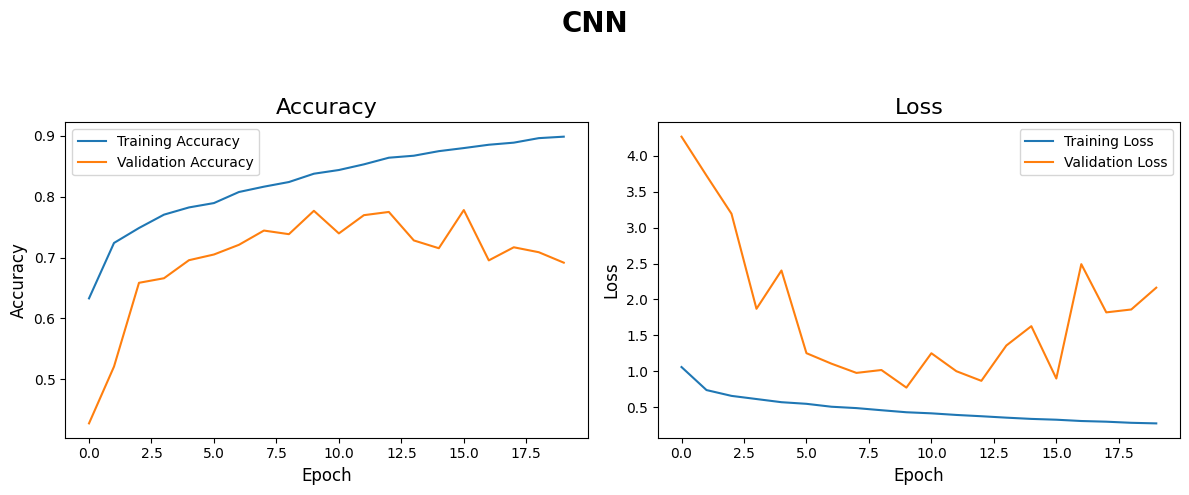

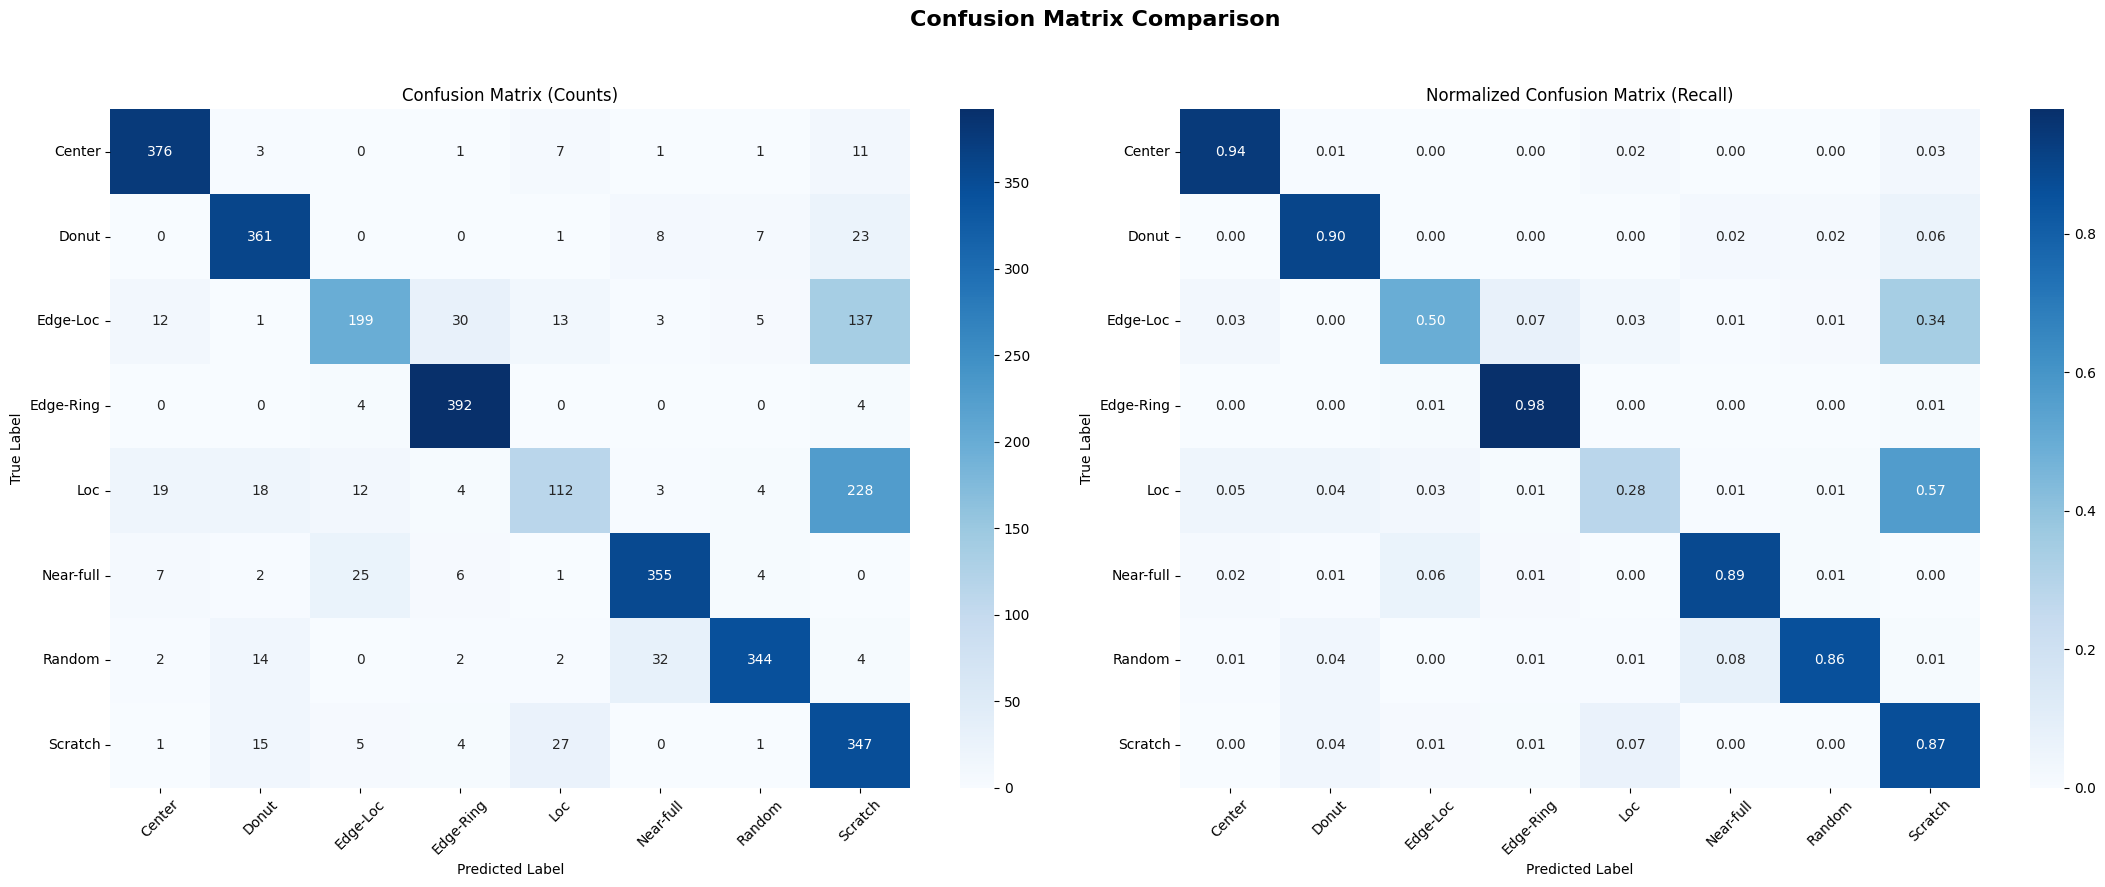

In [11]:
y_pred_probs = cnn_model.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "CNN")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **MobileNetV2**

In [12]:
# 1. 사전 학습된 MobileNetV2 모델 로드 (베이스 모델)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# 2. 베이스 모델의 가중치를 동결 (학습되지 않도록 설정)
base_model.trainable = False

# 3. 새로운 분류기(Classifier) 추가
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Flatten 대신 사용, 과적합 방지에 효과적
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# << 변경 1: 출력층을 8개 클래스에 맞게 수정 >>
predictions = Dense(8, activation='softmax')(x)

# 4. 베이스 모델과 새로운 분류기 결합
v2_model = Model(inputs=base_model.input, outputs=predictions)

# 5. 모델 컴파일
# << 변경 2: 손실 함수를 다중 클래스용으로 수정 >>
v2_model.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 모델 요약 정보 출력
v2_model.summary()

# 조기 종료 콜백
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


# 6. 모델 학습
hist = v2_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/50
800/800 - 20s - 26ms/step - accuracy: 0.5548 - loss: 1.2432 - val_accuracy: 0.7278 - val_loss: 0.7692
Epoch 2/50
800/800 - 7s - 9ms/step - accuracy: 0.6878 - loss: 0.8282 - val_accuracy: 0.7553 - val_loss: 0.6554
Epoch 3/50
800/800 - 7s - 9ms/step - accuracy: 0.7205 - loss: 0.7422 - val_accuracy: 0.7644 - val_loss: 0.6159
Epoch 4/50
800/800 - 8s - 10ms/step - accuracy: 0.7341 - loss: 0.6937 - val_accuracy: 0.7766 - val_loss: 0.5899
Epoch 5/50
800/800 - 8s - 9ms/step - accuracy: 0.7484 - loss: 0.6477 - val_accuracy: 0.7812 - val_loss: 0.5695
Epoch 6/50
800/800 - 8s - 10ms/step - accuracy: 0.7634 - loss: 0.6180 - val_accuracy: 0.8003 - val_loss: 0.5436
Epoch 7/50
800/800 - 8s - 10ms/step - accuracy: 0.7734 - loss: 0.5966 - val_accuracy: 0.7909 - val_loss: 0.5372
Epoch 8/50
800/800 - 8s - 10ms/step - accuracy: 0.7784 - loss: 0.5735 - val_accuracy: 0.8028 - val_loss: 0.5266
Epoch 9/50
800/800 - 8s - 10ms/step - accuracy: 0.7904 - loss: 0.5470 - val_accuracy: 0.8016 - val_loss: 0

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
Accuracy: 0.8331

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.83      0.86      0.85       400
       Donut       0.90      0.93      0.92       400
    Edge-Loc       0.61      0.71      0.66       400
   Edge-Ring       0.98      0.94      0.96       400
         Loc       0.60      0.55      0.57       400
   Near-full       0.98      0.98      0.98       400
      Random       0.92      0.94      0.93       400
     Scratch       0.84      0.76      0.80       400

    accuracy                           0.83      3200
   macro avg       0.84      0.83      0.83      3200
weighted avg       0.84      0.83      0.83      3200



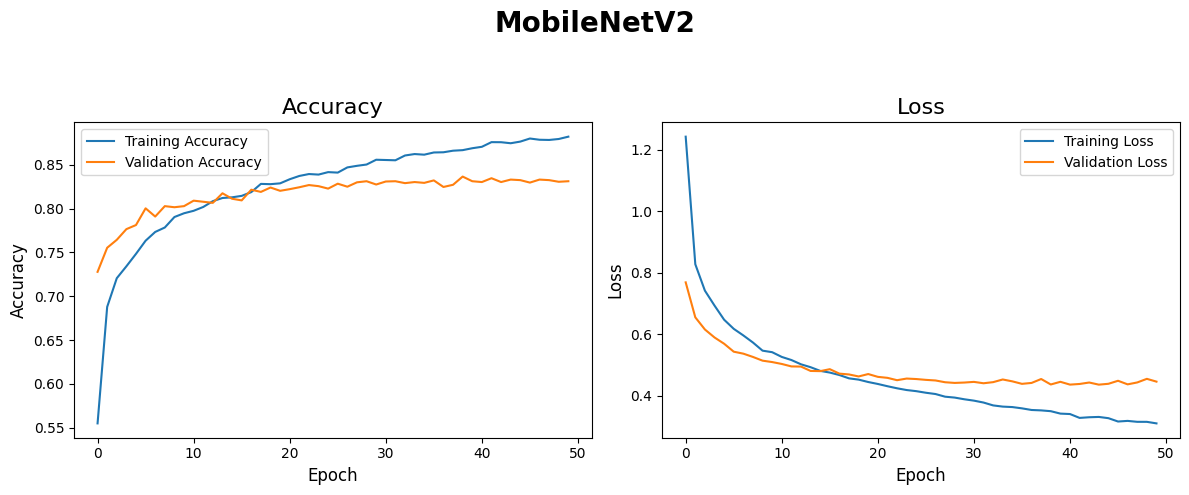

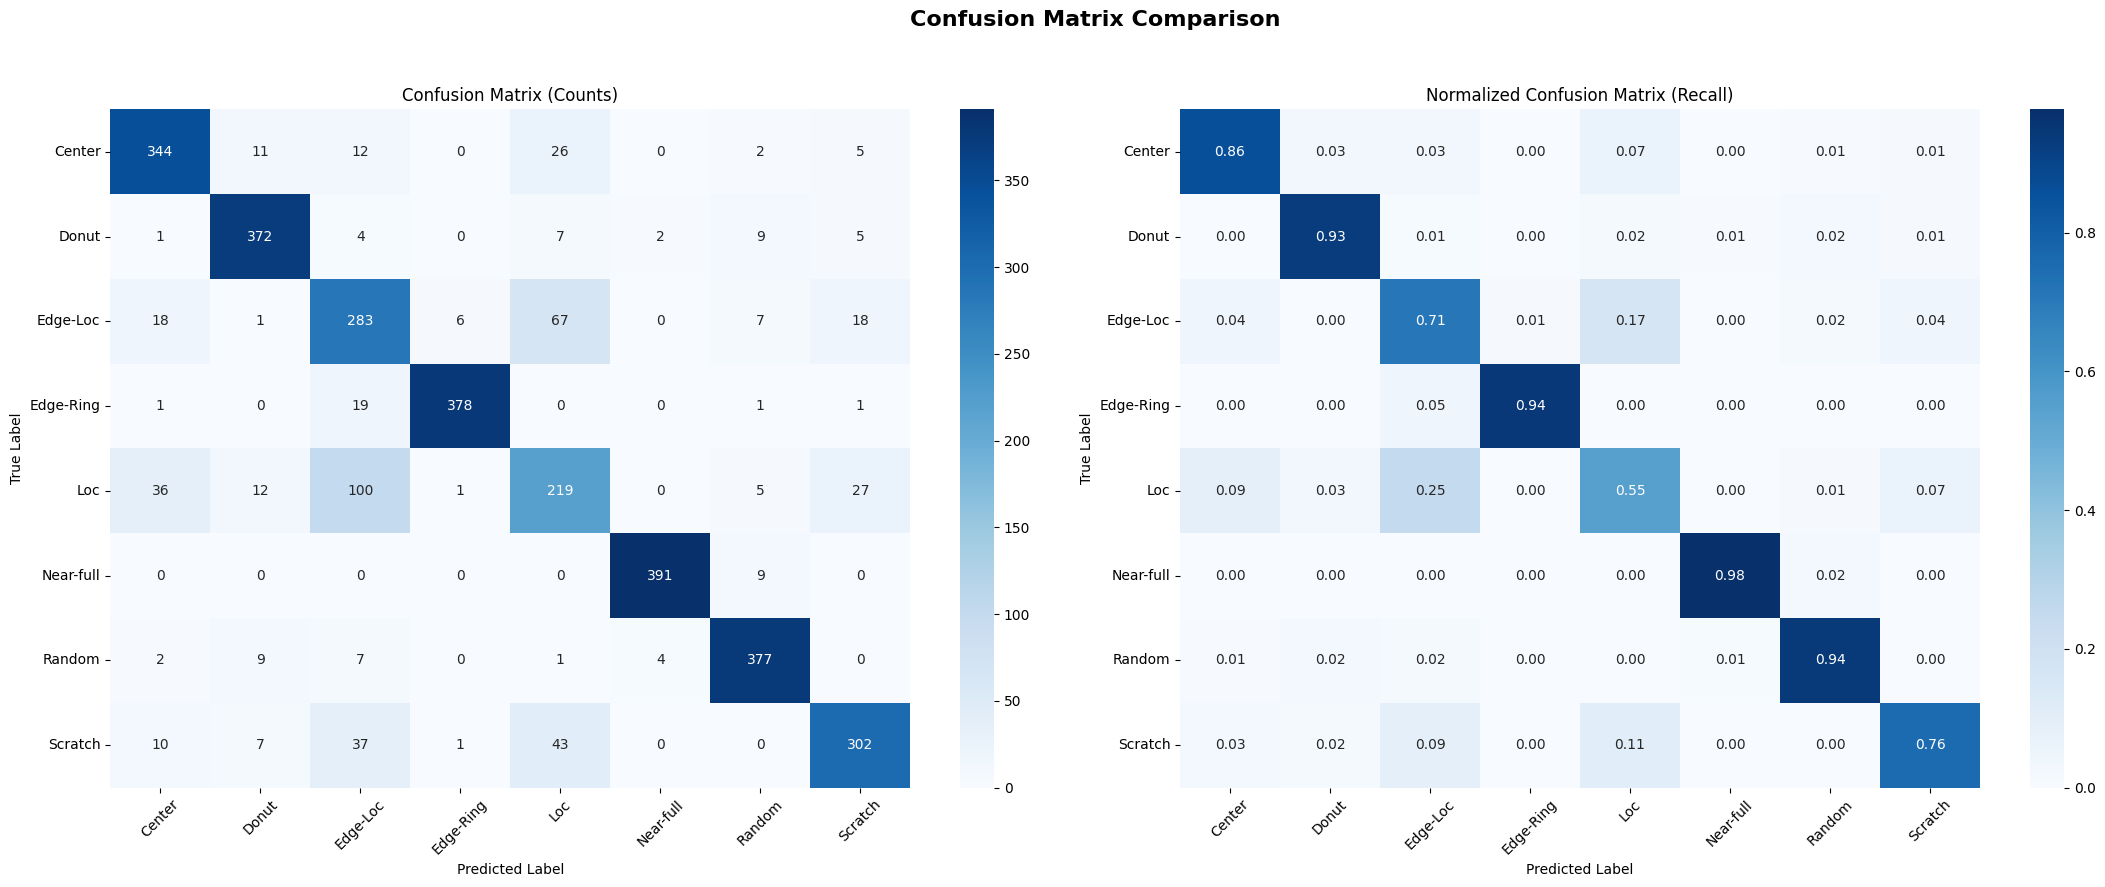

In [13]:
y_pred_probs = v2_model.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "MobileNetV2")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **MobileNetV3Small**

In [14]:
from tensorflow.keras.applications import MobileNetV3Small

base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

# Combine the base model with custom layers
v3_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the transfer learning model
transfer_optimizer = Adam(learning_rate=0.0001)
v3_model.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Display the transfer learning model summary
v3_model.summary()

# Train the transfer learning model
hist = v3_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

/usr/local/lib/python3.11/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        256 │ expanded_conv_sq

 Total params: 1,014,008 (3.87 MB)

 Trainable params: 74,888 (292.53 KB)

 Non-trainable params: 939,120 (3.58 MB)

Epoch 1/50
800/800 - 20s - 25ms/step - accuracy: 0.1895 - loss: 2.0724 - val_accuracy: 0.3247 - val_loss: 1.9894
Epoch 2/50
800/800 - 5s - 7ms/step - accuracy: 0.2878 - loss: 1.9564 - val_accuracy: 0.4494 - val_loss: 1.8960
Epoch 3/50
800/800 - 5s - 7ms/step - accuracy: 0.3259 - loss: 1.8706 - val_accuracy: 0.4034 - val_loss: 1.8063
Epoch 4/50
800/800 - 5s - 7ms/step - accuracy: 0.3585 - loss: 1.7996 - val_accuracy: 0.4794 - val_loss: 1.7418
Epoch 5/50
800/800 - 5s - 7ms/step - accuracy: 0.3760 - loss: 1.7418 - val_accuracy: 0.4487 - val_loss: 1.6787
Epoch 6/50
800/800 - 5s - 7ms/step - accuracy: 0.3975 - loss: 1.6925 - val_accuracy: 0.5166 - val_loss: 1.6236
Epoch 7/50
800/800 - 5s - 7ms/step - accuracy: 0.4196 - loss: 1.6446 - val_accuracy: 0.5169 - val_loss: 1.5811
Epoch 8/50
800/800 - 5s - 7ms/step - accuracy: 0.4339 - loss: 1.6087 - val_accuracy: 0.5309 - val_loss: 1.5363
Epoch 9/50
800/800 - 5s - 6ms/step - accuracy: 0.4452 - loss: 1.5704 - val_accuracy: 0.5369 - val_loss: 1.5011

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
Accuracy: 0.6353

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.47      0.57      0.51       400
       Donut       0.65      0.74      0.69       400
    Edge-Loc       0.53      0.46      0.49       400
   Edge-Ring       0.91      0.91      0.91       400
         Loc       0.30      0.20      0.24       400
   Near-full       0.85      0.82      0.83       400
      Random       0.84      0.83      0.83       400
     Scratch       0.47      0.55      0.51       400

    accuracy                           0.64      3200
   macro avg       0.63      0.64      0.63      3200
weighted avg       0.63      0.64      0.63      3200



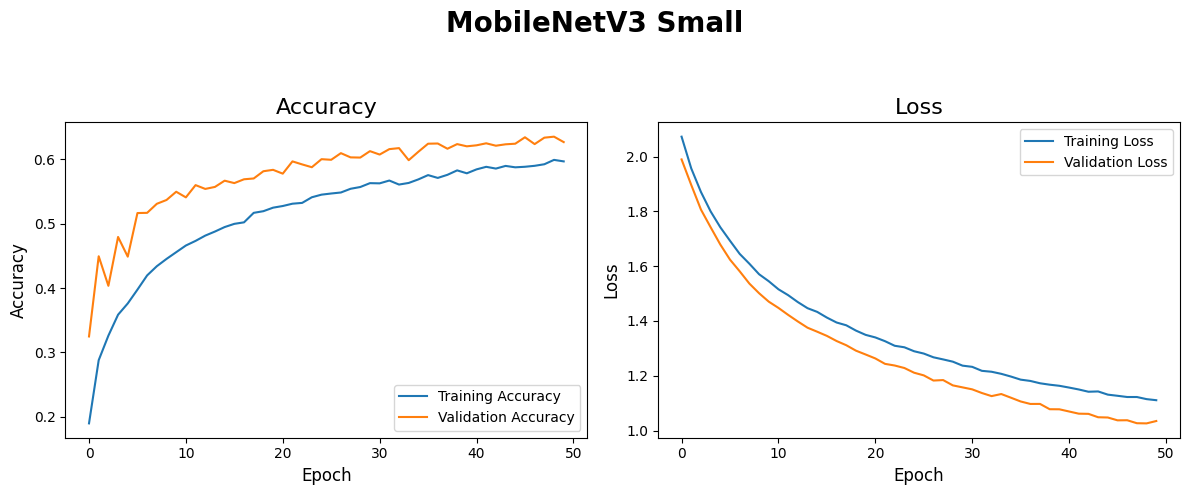

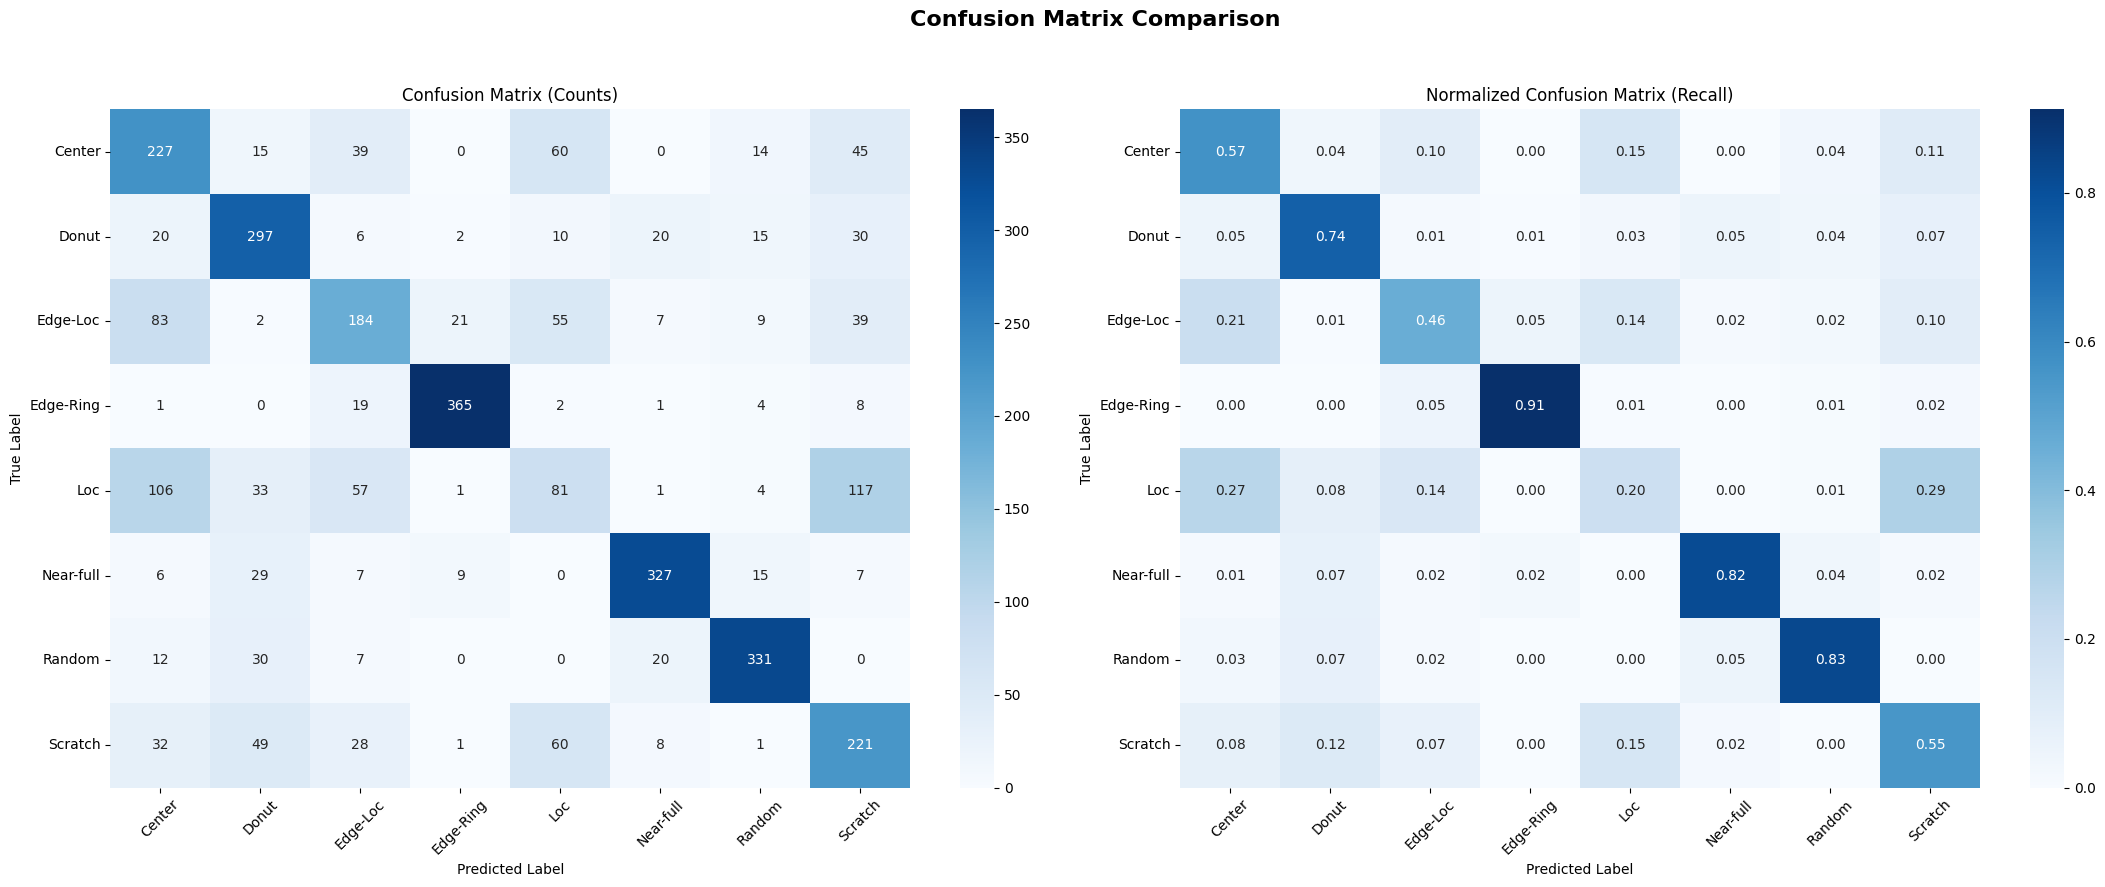

In [15]:
y_pred_probs = v3_model.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "MobileNetV3 Small")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **ResNet50**

In [16]:
from tensorflow.keras.applications import ResNet50

X_train_reshaped = X_train.reshape(-1, 128, 128, 3)
X_test_reshaped = X_test.reshape(-1, 128, 128, 3)

# ResNet50 모델 불러오기
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom top layers for your specific dataset
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

# Combine the base model with custom layers
resnet50_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the transfer learning model
transfer_optimizer = Adam(learning_rate=0.0001)
resnet50_model.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Display the transfer learning model summary
resnet50_model.summary()

# Train the transfer learning model
hist = resnet50_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/50
800/800 - 34s - 42ms/step - accuracy: 0.1459 - loss: 2.1135 - val_accuracy: 0.2516 - val_loss: 2.0416
Epoch 2/50
800/800 - 18s - 22ms/step - accuracy: 0.2384 - loss: 2.0285 - val_accuracy: 0.3300 - val_loss: 2.0007
Epoch 3/50
800/800 - 18s - 22ms/step - accuracy: 0.3050 - loss: 1.9821 - val_accuracy: 0.4097 - val_loss: 1.9445
Epoch 4/50
800/800 - 18s - 22ms/step - accuracy: 0.3325 - loss: 1.9244 - val_accuracy: 0.3922 - val_loss: 1.8793
Epoch 5/50
800/800 - 18s - 22ms/step - accuracy: 0.3711 - loss: 1.8592 - val_accuracy: 0.4997 - val_loss: 1.8064
Epoch 6/50
800/800 - 18s - 22ms/step - accuracy: 0.3952 - loss: 1.7928 - val_accuracy: 0.4994 - val_loss: 1.7348
Epoch 7/50
800/800 - 18s - 22ms/step - accuracy: 0.4179 - loss: 1.7266 - val_accuracy: 0.4762 - val_loss: 1.6682
Epoch 8/50
800/800 - 18s - 22ms/step - accuracy: 0.4327 - loss: 1.6636 - val_accuracy: 0.5541 - val_loss: 1.6029
Epoch 9/50
800/800 - 18s - 22ms/step - accuracy: 0.4606 - loss: 1.6055 - val_accuracy: 0.5378 - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step
Accuracy: 0.6319

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.49      0.56      0.52       400
       Donut       0.64      0.68      0.66       400
    Edge-Loc       0.51      0.45      0.48       400
   Edge-Ring       0.92      0.92      0.92       400
         Loc       0.32      0.25      0.28       400
   Near-full       0.91      0.87      0.89       400
      Random       0.76      0.86      0.80       400
     Scratch       0.46      0.48      0.47       400

    accuracy                           0.63      3200
   macro avg       0.62      0.63      0.63      3200
weighted avg       0.62      0.63      0.63      3200



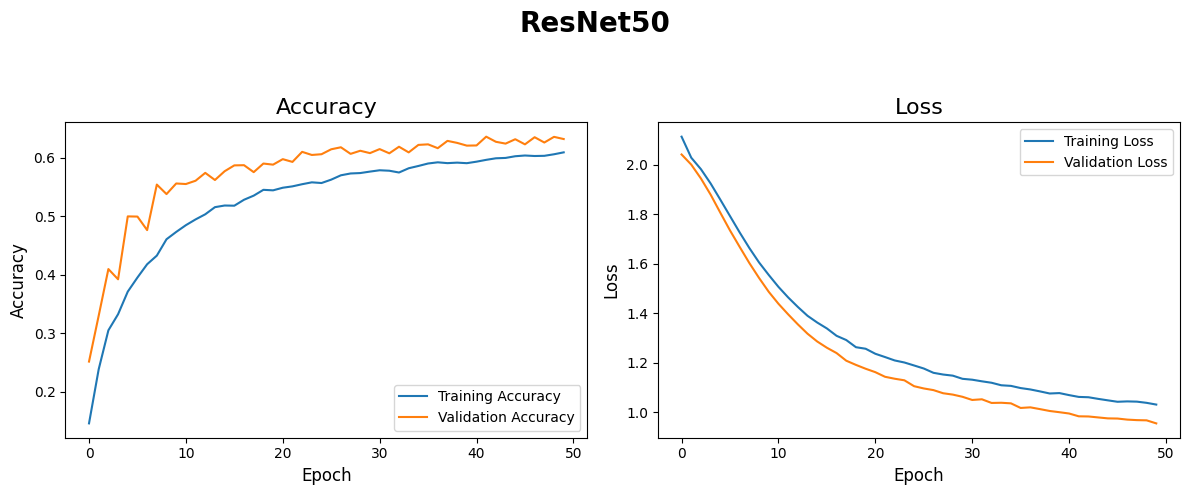

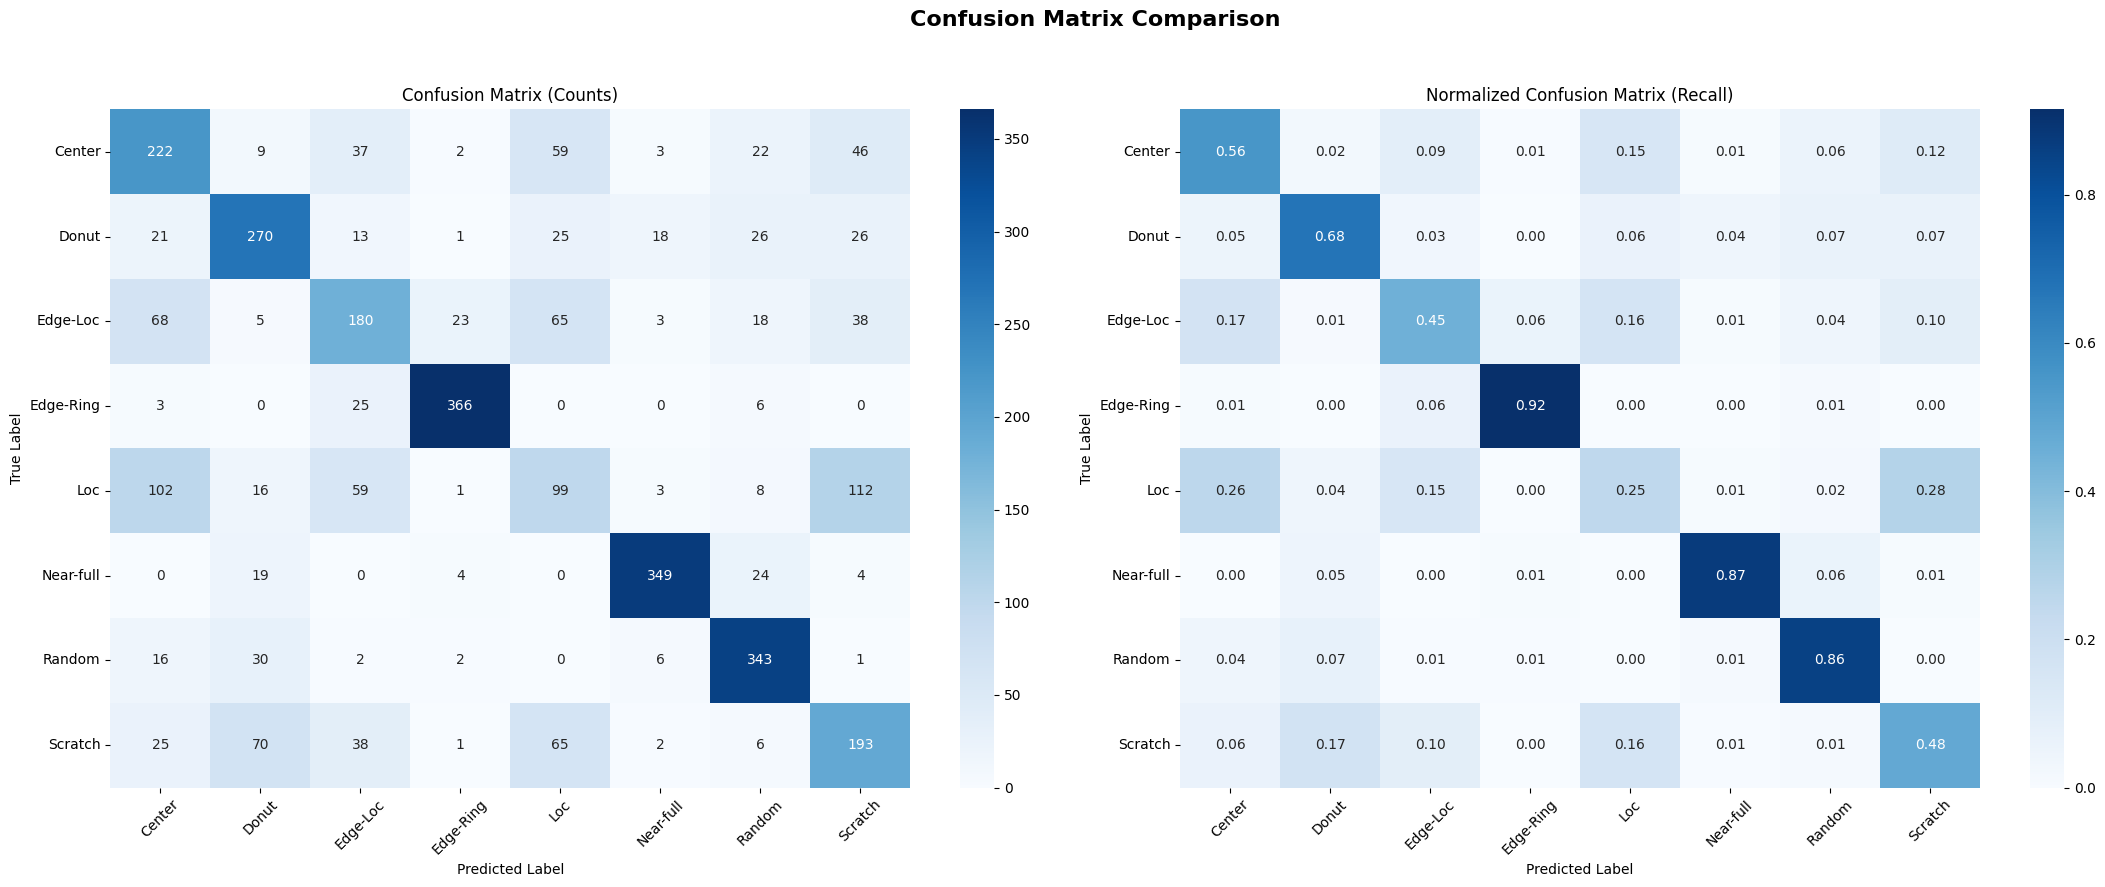

In [17]:
y_pred_probs = resnet50_model.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "ResNet50")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **VGG16**

In [18]:
from tensorflow.keras.applications import VGG16

# VGG16 모델 불러오기
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom top layers for your specific dataset
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

# Combine the base model with custom layers
model_vgg = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_vgg.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

model_vgg.summary()

history_transfer = model_vgg.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,384 (56.39 MB)

 Trainable params: 66,696 (260.53 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/50
800/800 - 41s - 51ms/step - accuracy: 0.3691 - loss: 1.7914 - val_accuracy: 0.6131 - val_loss: 1.3708
Epoch 2/50
800/800 - 32s - 41ms/step - accuracy: 0.5689 - loss: 1.2868 - val_accuracy: 0.6737 - val_loss: 1.0746
Epoch 3/50
800/800 - 32s - 40ms/step - accuracy: 0.6273 - loss: 1.0888 - val_accuracy: 0.6934 - val_loss: 0.9254
Epoch 4/50
800/800 - 32s - 41ms/step - accuracy: 0.6523 - loss: 0.9799 - val_accuracy: 0.7156 - val_loss: 0.8366
Epoch 5/50
800/800 - 32s - 40ms/step - accuracy: 0.6810 - loss: 0.9019 - val_accuracy: 0.7300 - val_loss: 0.7741
Epoch 6/50
800/800 - 32s - 40ms/step - accuracy: 0.6915 - loss: 0.8473 - val_accuracy: 0.7459 - val_loss: 0.7285
Epoch 7/50
800/800 - 32s - 40ms/step - accuracy: 0.7075 - loss: 0.8079 - val_accuracy: 0.7538 - val_loss: 0.6957
Epoch 8/50
800/800 - 32s - 40ms/step - accuracy: 0.7163 - loss: 0.7758 - val_accuracy: 0.7656 - val_loss: 0.6676
Epoch 9/50
800/800 - 32s - 40ms/step - accuracy: 0.7262 - loss: 0.7496 - val_accuracy: 0.7703 - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step
Accuracy: 0.8381

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.83      0.81      0.82       400
       Donut       0.91      0.94      0.93       400
    Edge-Loc       0.65      0.71      0.68       400
   Edge-Ring       0.97      0.95      0.96       400
         Loc       0.62      0.52      0.56       400
   Near-full       0.99      0.99      0.99       400
      Random       0.92      0.96      0.94       400
     Scratch       0.81      0.81      0.81       400

    accuracy                           0.84      3200
   macro avg       0.84      0.84      0.84      3200
weighted avg       0.84      0.84      0.84      3200



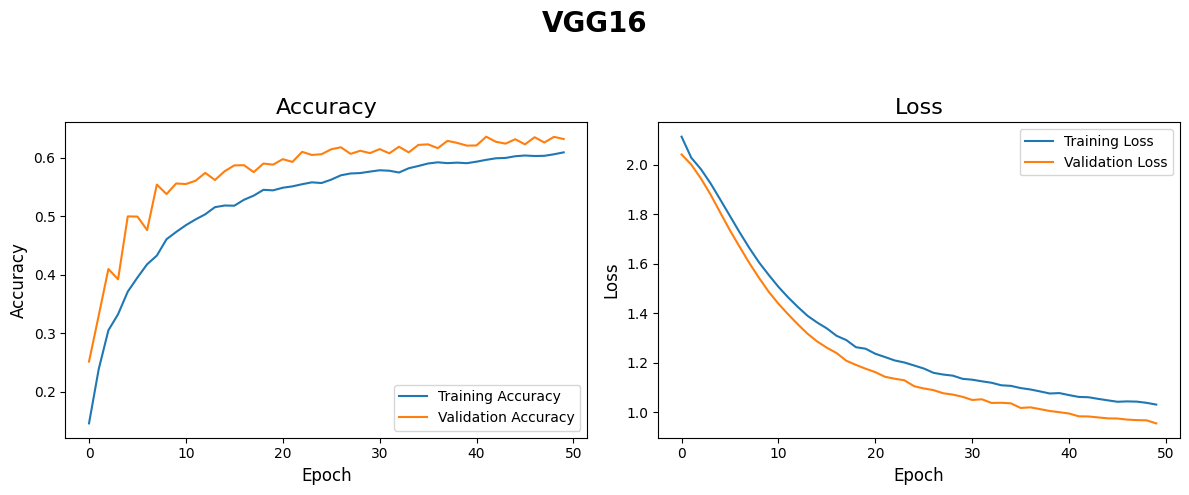

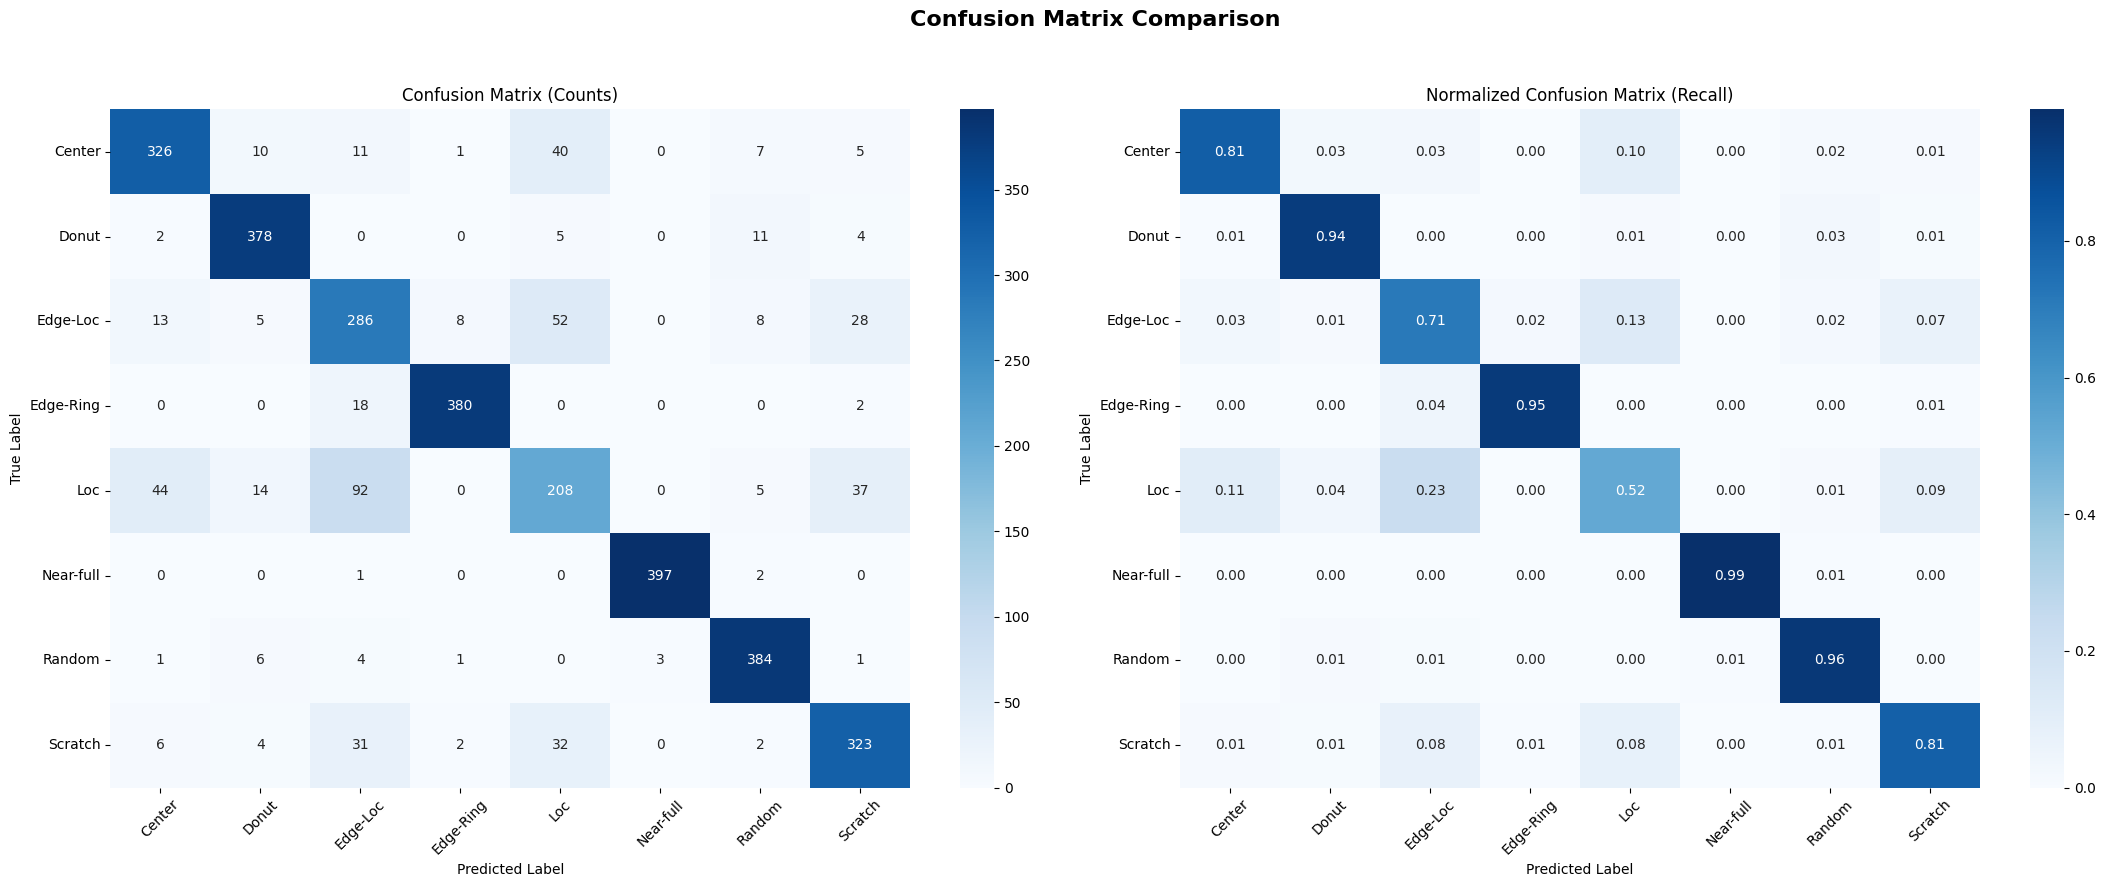

In [19]:
y_pred_probs = model_vgg.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "VGG16")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **InceptionV3**

In [20]:
from tensorflow.keras.applications import InceptionV3

# InceptionV3 모델 불러오기
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom top layers for your specific dataset
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

# Combine the base model with custom layers
model_inception = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_inception.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

model_inception.summary()

history_transfer = model_inception.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 63, 63,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 63, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │      9,216 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 61, 61,    │     18,432 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 30, 30,    │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 30, 30,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │        240 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │    138,240 │ activation_21[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        576 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 22,066,088 (84.18 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/50
800/800 - 36s - 45ms/step - accuracy: 0.5281 - loss: 1.3279 - val_accuracy: 0.7044 - val_loss: 0.8093
Epoch 2/50
800/800 - 15s - 19ms/step - accuracy: 0.6655 - loss: 0.9139 - val_accuracy: 0.7428 - val_loss: 0.6929
Epoch 3/50
800/800 - 15s - 19ms/step - accuracy: 0.6984 - loss: 0.8103 - val_accuracy: 0.7506 - val_loss: 0.6633
Epoch 4/50
800/800 - 15s - 19ms/step - accuracy: 0.7182 - loss: 0.7423 - val_accuracy: 0.7547 - val_loss: 0.6460
Epoch 5/50
800/800 - 15s - 19ms/step - accuracy: 0.7270 - loss: 0.7150 - val_accuracy: 0.7803 - val_loss: 0.5912
Epoch 6/50
800/800 - 15s - 19ms/step - accuracy: 0.7408 - loss: 0.6746 - val_accuracy: 0.7812 - val_loss: 0.5888
Epoch 7/50
800/800 - 15s - 19ms/step - accuracy: 0.7459 - loss: 0.6590 - val_accuracy: 0.7844 - val_loss: 0.5709
Epoch 8/50
800/800 - 15s - 19ms/step - accuracy: 0.7573 - loss: 0.6255 - val_accuracy: 0.7934 - val_loss: 0.5582
Epoch 9/50
800/800 - 15s - 19ms/step - accuracy: 0.7616 - loss: 0.6150 - val_accuracy: 0.7816 - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step
Accuracy: 0.8150

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.83      0.83      0.83       400
       Donut       0.88      0.87      0.87       400
    Edge-Loc       0.61      0.74      0.67       400
   Edge-Ring       0.97      0.92      0.95       400
         Loc       0.62      0.51      0.56       400
   Near-full       0.96      0.95      0.96       400
      Random       0.88      0.90      0.89       400
     Scratch       0.79      0.79      0.79       400

    accuracy                           0.81      3200
   macro avg       0.82      0.81      0.81      3200
weighted avg       0.82      0.81      0.81      3200



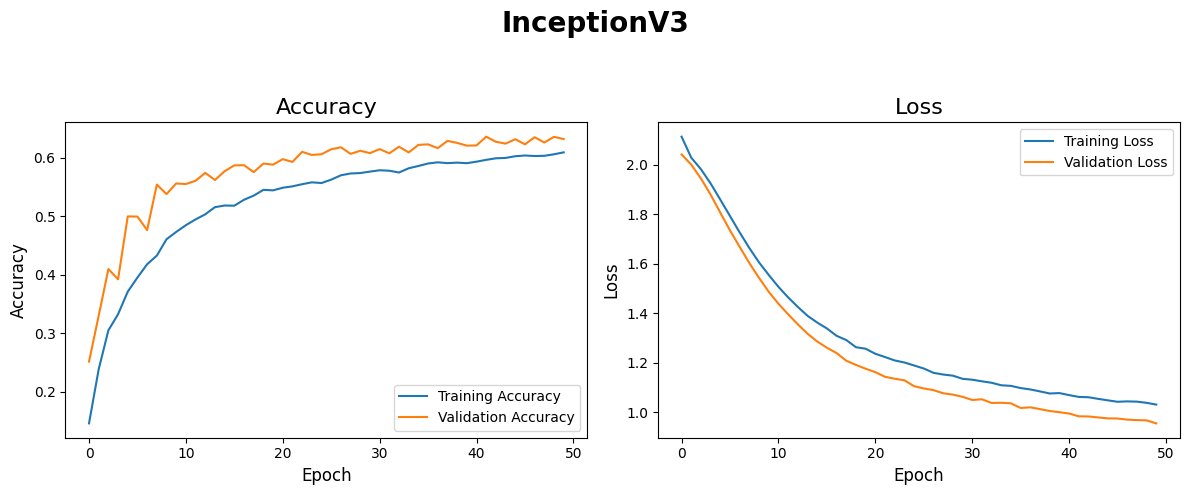

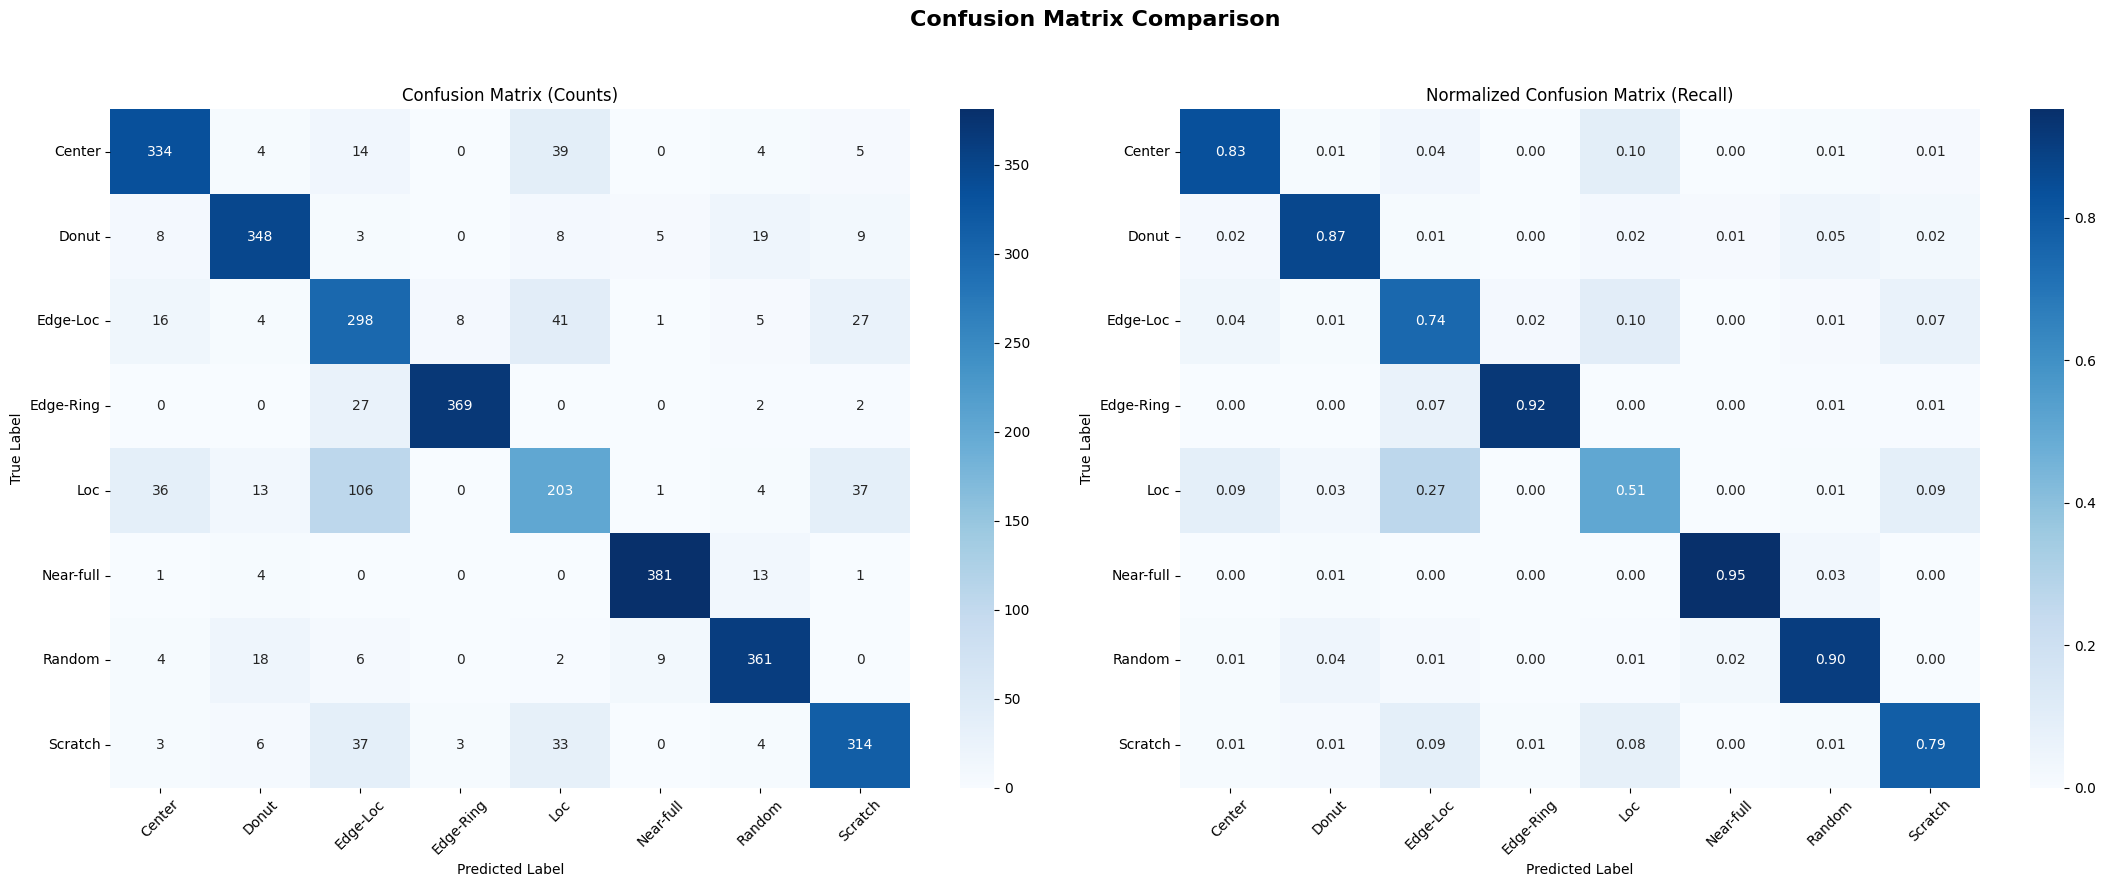

In [21]:
y_pred_probs = model_inception.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "InceptionV3")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **Xception**

In [22]:
from tensorflow.keras.applications import Xception

# Xception 모델 불러오기
base_model = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom top layers for your specific dataset
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

# Combine the base model with custom layers
model_xception = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_xception.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

model_xception.summary()

history_transfer = model_xception.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ input_layer_7[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        512 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add_9[0][0]     

 Total params: 21,124,784 (80.58 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/50
800/800 - 33s - 41ms/step - accuracy: 0.5792 - loss: 1.1758 - val_accuracy: 0.7044 - val_loss: 0.8177
Epoch 2/50
800/800 - 21s - 27ms/step - accuracy: 0.6863 - loss: 0.8536 - val_accuracy: 0.7341 - val_loss: 0.7150
Epoch 3/50
800/800 - 21s - 26ms/step - accuracy: 0.7165 - loss: 0.7674 - val_accuracy: 0.7534 - val_loss: 0.6653
Epoch 4/50
800/800 - 20s - 26ms/step - accuracy: 0.7298 - loss: 0.7133 - val_accuracy: 0.7547 - val_loss: 0.6349
Epoch 5/50
800/800 - 20s - 26ms/step - accuracy: 0.7480 - loss: 0.6700 - val_accuracy: 0.7597 - val_loss: 0.6183
Epoch 6/50
800/800 - 21s - 26ms/step - accuracy: 0.7545 - loss: 0.6515 - val_accuracy: 0.7675 - val_loss: 0.5971
Epoch 7/50
800/800 - 20s - 26ms/step - accuracy: 0.7634 - loss: 0.6281 - val_accuracy: 0.7759 - val_loss: 0.5863
Epoch 8/50
800/800 - 20s - 25ms/step - accuracy: 0.7711 - loss: 0.6073 - val_accuracy: 0.7703 - val_loss: 0.5898
Epoch 9/50
800/800 - 20s - 26ms/step - accuracy: 0.7770 - loss: 0.5929 - val_accuracy: 0.7803 - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step
Accuracy: 0.8147

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.84      0.78      0.81       400
       Donut       0.89      0.92      0.90       400
    Edge-Loc       0.61      0.63      0.62       400
   Edge-Ring       0.95      0.92      0.93       400
         Loc       0.54      0.61      0.58       400
   Near-full       0.97      0.97      0.97       400
      Random       0.93      0.94      0.94       400
     Scratch       0.83      0.74      0.79       400

    accuracy                           0.81      3200
   macro avg       0.82      0.81      0.82      3200
weighted avg       0.82      0.81      0.82      3200



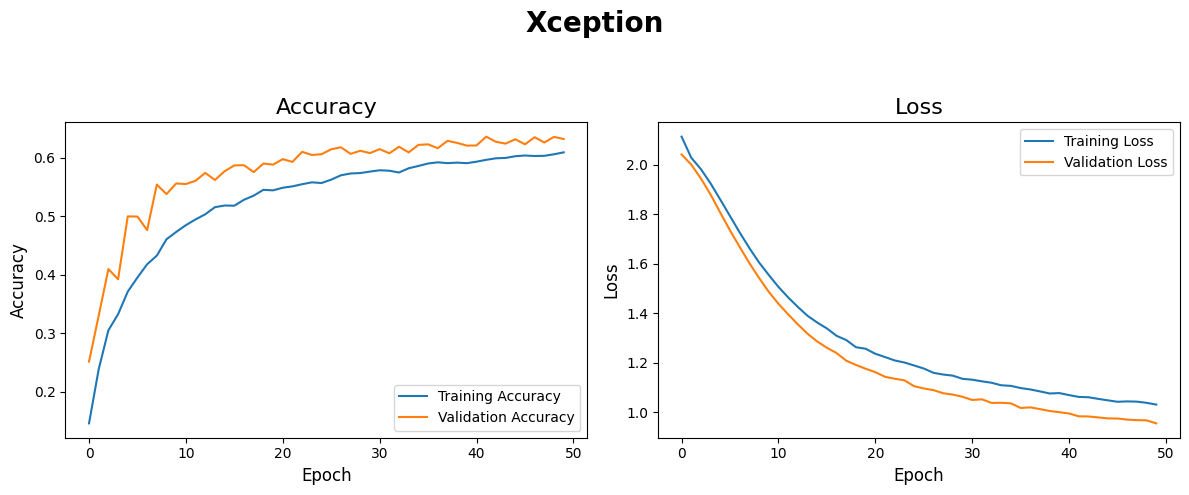

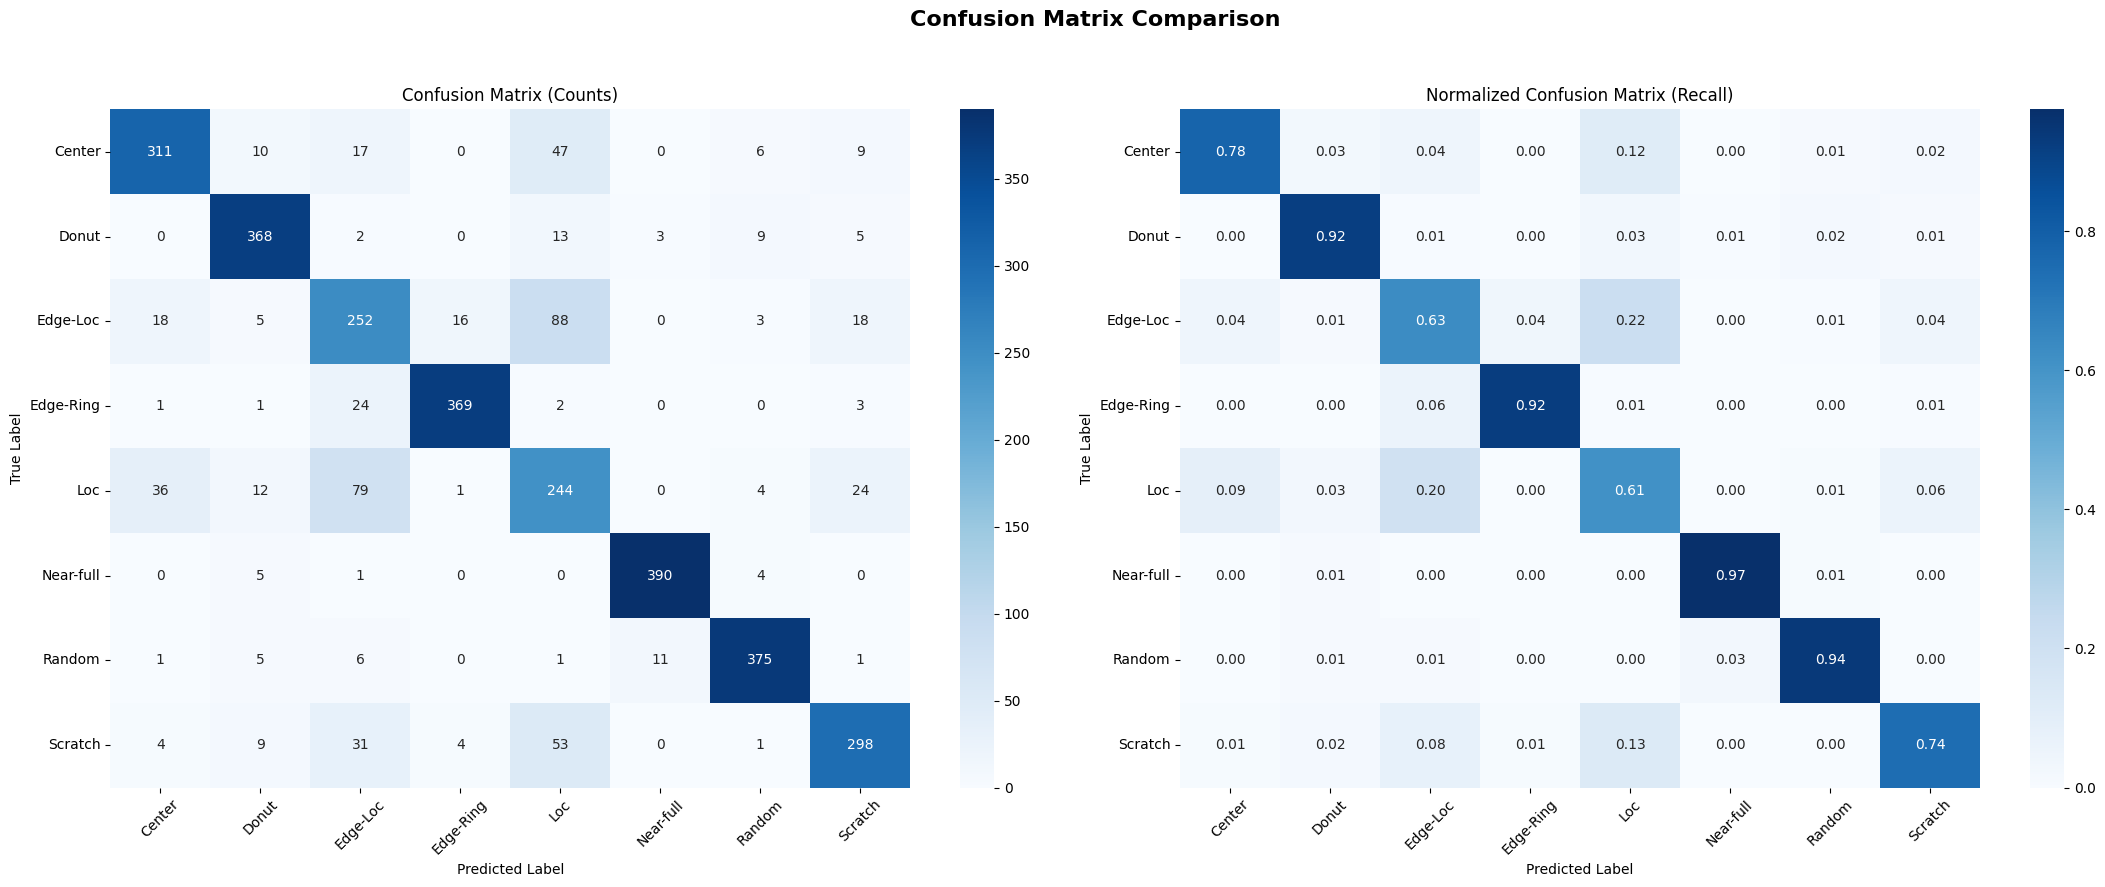

In [23]:
y_pred_probs = model_xception.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "Xception")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **DenseNet121**

In [24]:
from tensorflow.keras.applications import DenseNet121

# DenseNet121 모델 불러오기
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom top layers for your specific dataset
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

# Combine the base model with custom layers
model_densenet = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_densenet.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

model_densenet.summary()

history_transfer = model_densenet.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,169,736 (27.35 MB)

 Trainable params: 132,232 (516.53 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/50
800/800 - 54s - 67ms/step - accuracy: 0.4815 - loss: 1.4832 - val_accuracy: 0.6747 - val_loss: 0.9085
Epoch 2/50
800/800 - 18s - 23ms/step - accuracy: 0.6381 - loss: 0.9737 - val_accuracy: 0.7237 - val_loss: 0.7540
Epoch 3/50
800/800 - 19s - 23ms/step - accuracy: 0.6777 - loss: 0.8521 - val_accuracy: 0.7375 - val_loss: 0.6822
Epoch 4/50
800/800 - 18s - 23ms/step - accuracy: 0.7017 - loss: 0.7774 - val_accuracy: 0.7553 - val_loss: 0.6391
Epoch 5/50
800/800 - 18s - 22ms/step - accuracy: 0.7205 - loss: 0.7300 - val_accuracy: 0.7659 - val_loss: 0.6076
Epoch 6/50
800/800 - 18s - 23ms/step - accuracy: 0.7321 - loss: 0.6910 - val_accuracy: 0.7719 - val_loss: 0.5877
Epoch 7/50
800/800 - 18s - 23ms/step - accuracy: 0.7408 - loss: 0.6696 - val_accuracy: 0.7731 - val_loss: 0.5851
Epoch 8/50
800/800 - 18s - 23ms/step - accuracy: 0.7490 - loss: 0.6467 - val_accuracy: 0.7841 - val_loss: 0.5573
Epoch 9/50
800/800 - 18s - 23ms/step - accuracy: 0.7546 - loss: 0.6228 - val_accuracy: 0.7916 - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step
Accuracy: 0.8328

--- Classification Report ---

              precision    recall  f1-score   support

      Center       0.82      0.79      0.81       400
       Donut       0.91      0.94      0.92       400
    Edge-Loc       0.63      0.71      0.67       400
   Edge-Ring       0.97      0.94      0.95       400
         Loc       0.59      0.60      0.59       400
   Near-full       0.98      1.00      0.99       400
      Random       0.95      0.93      0.94       400
     Scratch       0.85      0.77      0.80       400

    accuracy                           0.83      3200
   macro avg       0.84      0.83      0.83      3200
weighted avg       0.84      0.83      0.83      3200



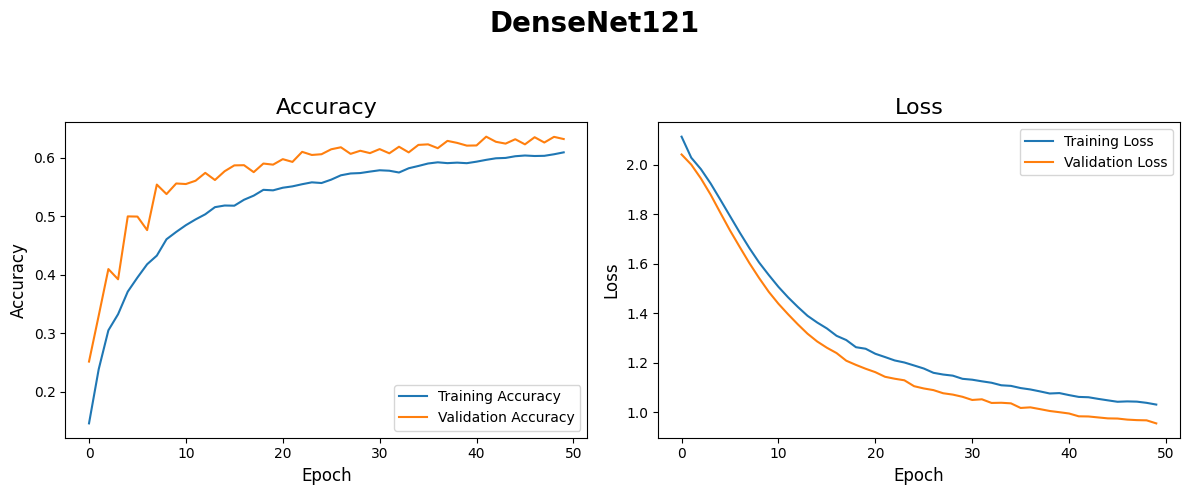

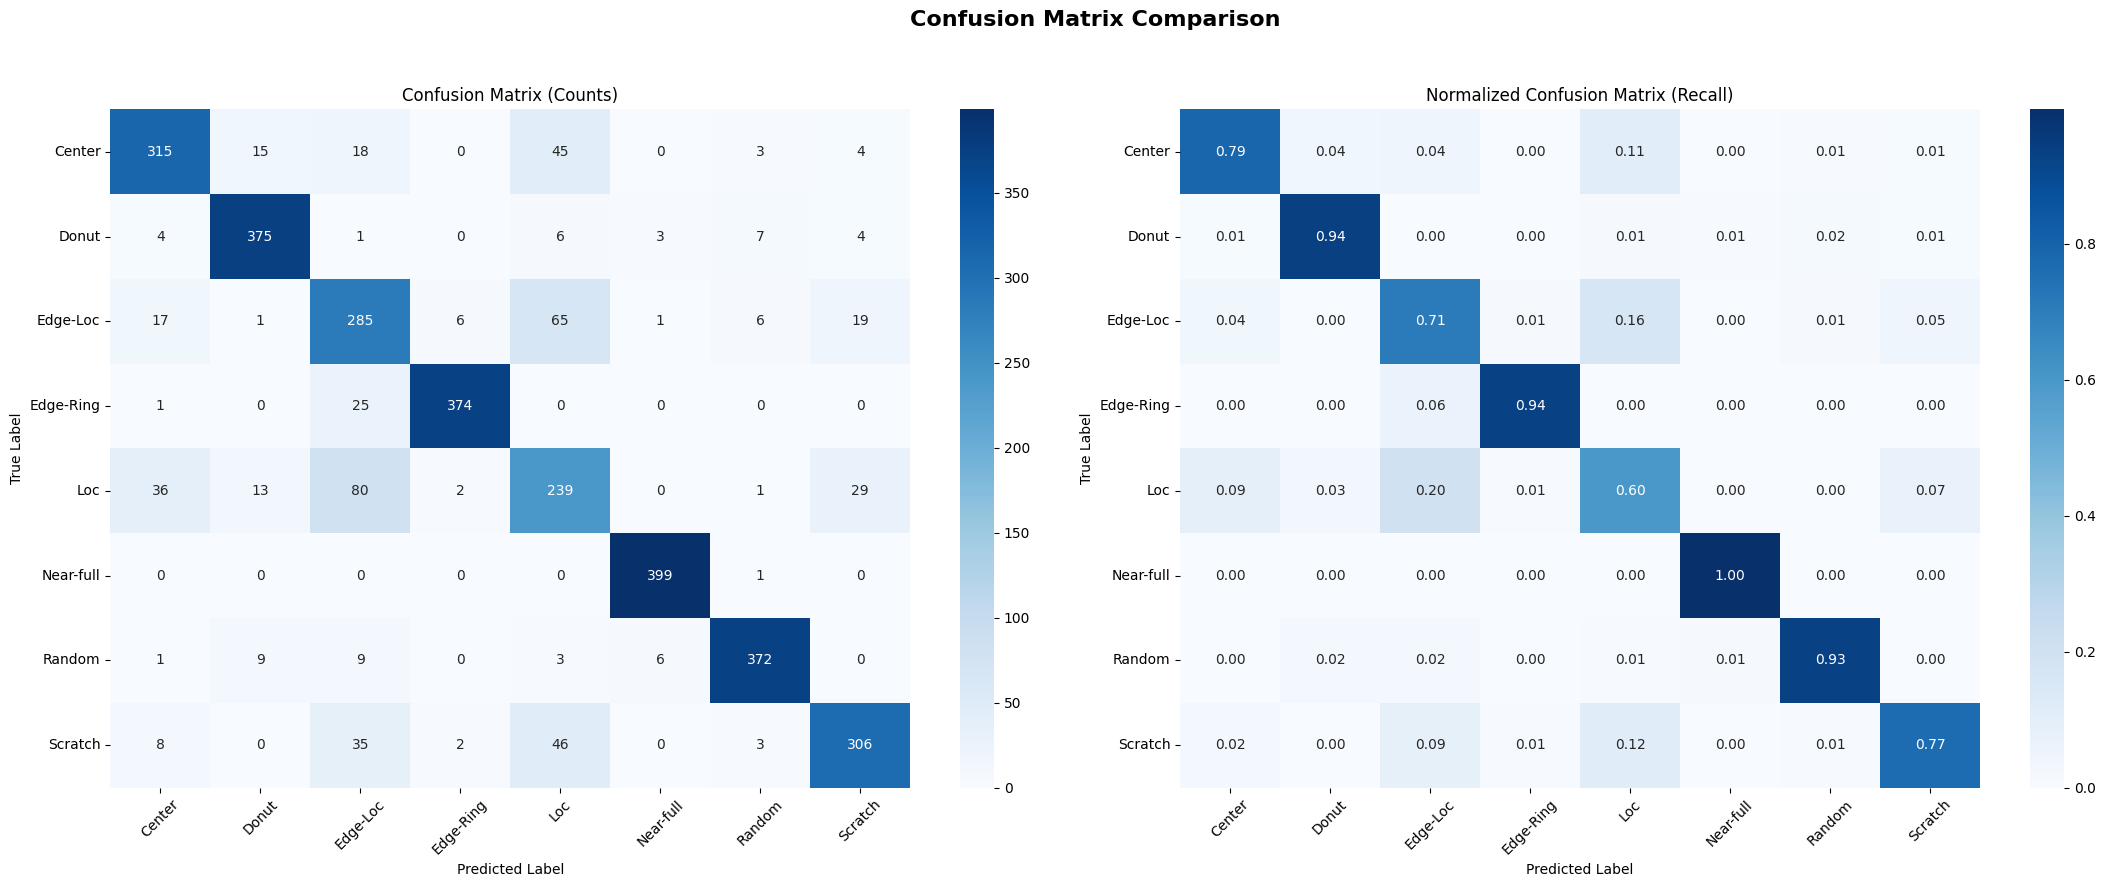

In [25]:
y_pred_probs = model_densenet.predict(X_test)

# << 변경 >>: softmax 출력(각 클래스일 확률)에서 가장 높은 확률을 가진 인덱스를 예측 클래스로 변환합니다.
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test # 실제 정답 라벨

# 정확도 계산 (코드는 동일)
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")

# 분류 리포트 출력
display_classification_report(y_true, y_pred_classes, class_names)

# 학습 히스토리 시각화
plot_history(hist.history, "DenseNet121")

# 혼동 행렬 그리기
plot_confusion_matrices(y_true, y_pred_classes, class_names)

## **성능 비교**

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 모델 정의
models = {
    "DNN (Deep Neural Network)": model_dnn,
    "CNN (Convolutional Neural Network)": cnn_model,
    "MobileNetV2": v2_model,
    "MobileNetV3Small": v3_model,
    "ResNet50": resnet50_model,
    "VGG16": model_vgg,
    "InceptionV3": model_inception,
    "Xception": model_xception,
    "DenseNet121": model_densenet
}

# 결과 저장용 리스트
results = []

# 데이터프레임 생성을 위한 루프
for model_name, model in models.items():
    # 예측 수행
    y_pred = model.predict(X_test, verbose=0)

    # << 변경 1: softmax 출력에 맞게 예측 클래스 변환 >>
    y_pred_classes = np.argmax(y_pred, axis=1)

    # 정확도, 정밀도, 재현율, F1-score 계산
    accuracy = accuracy_score(y_test, y_pred_classes)

    # << 변경 2: 다중 클래스용 average='macro' 옵션 추가 >>
    precision = precision_score(y_test, y_pred_classes, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred_classes, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred_classes, average='macro', zero_division=0)

    # 결과 저장
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1-Score (Macro)": f1
    })

# 데이터프레임 생성
results_df = pd.DataFrame(results)

# 출력
# 줄바꿈과 함께 출력
print("\n\n모델별 성능 정리:\n")
display(results_df)



모델별 성능 정리:



,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,DNN (Deep Neural Network),0.820000,0.823437,0.820000,0.818009
1,CNN (Convolutional Neural Network),0.776875,0.806143,0.776875,0.767704
2,MobileNetV2,0.833125,0.835122,0.833125,0.833115
3,MobileNetV3Small,0.635312,0.629148,0.635312,0.629270
4,ResNet50,0.631875,0.624436,0.631875,0.626605
5,VGG16,0.838125,0.835846,0.838125,0.836109
6,InceptionV3,0.815000,0.817368,0.815000,0.814459
7,Xception,0.814688,0.819757,0.814688,0.816468
8,DenseNet121,0.832812,0.836837,0.832812,0.834092
